# GP with Uncertain Inputs (PILCO-style)

When a Gaussian process (GP) is queried at an uncertain input
$x_* \sim \mathcal{N}(\mu_*, \Sigma_*)$, the predictive distribution
$p(f(x_*))$ is **no longer Gaussian** -- it is a mixture of Gaussians
weighted by the input density. Approximating this distribution is
central to several important models:

- **Multi-step dynamics prediction** (Girard et al., 2003): the GP
  predicts the next state, and that uncertain prediction becomes
  the input for the following step. Uncertainty compounds.
- **PILCO** (Deisenroth & Rasmussen, 2011): a GP dynamics model is
  rolled forward under a policy, and the expected cost is
  differentiated through the uncertain predictions to learn the policy.
- **Bayesian GPLVM** (Titsias & Lawrence, 2010): latent inputs are
  uncertain, so the likelihood requires integrating the GP over
  the variational posterior of the inputs.
- **Heteroscedastic / input-noise GPs** (McHutchon & Rasmussen, 2011):
  noisy inputs induce effective output noise that depends on the
  local gradient of the GP mean.

## Predictive moments

Given the GP posterior $f \mid \mathcal{D}$ with weights
$\alpha = (K + \sigma^2 I)^{-1} y$ and an uncertain input
$x_* \sim \mathcal{N}(\mu_*, \Sigma_*)$, the predictive moments are

$$\mathbb{E}[f(x_*)] = \int \mathbf{k}(x_*)^\top \alpha
  \;\mathcal{N}(x_* \mid \mu_*, \Sigma_*)\,dx_*,$$

$$\mathrm{Var}[f(x_*)] = \int \bigl(f(x_*)
  - \mathbb{E}[f(x_*)]\bigr)^2
  \;\mathcal{N}(x_* \mid \mu_*, \Sigma_*)\,dx_*.$$

For the squared-exponential kernel, these integrals have closed-form
solutions. For general kernels, we need numerical integration --
and that is where gaussx's uncertainty propagation machinery comes in.

## What this notebook covers

1. Training a 1D GP on $\sin(x)$ data
2. Single uncertain prediction with Taylor, Unscented, and MC methods
3. Multi-step dynamics rollout (PILCO-style) with growing uncertainty
4. Expected cost computation under input uncertainty
5. Expectation utilities: mean, gradient, and log-likelihood expectations
6. `AssumedDensityFilter` diagnostics: skewness, kurtosis, Gaussianity

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import jax.random as jr
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## 1. Setup: 1D GP regression on sin(x)

We train a standard GP with an RBF kernel on noisy observations of
$\sin(x)$, then extract the weight vector $\alpha = K^{-1} y$ and the
inverse kernel operator $K^{-1}$.

In [2]:
key = jr.PRNGKey(42)
n_train = 40
noise_var = 0.04

# Training data
key, subkey = jr.split(key)
X_train = jr.uniform(subkey, (n_train, 1), minval=-4.0, maxval=4.0)
y_train = jnp.sin(X_train[:, 0]) + jnp.sqrt(noise_var) * jr.normal(key, (n_train,))

### RBF kernel

In [3]:
lengthscale = 1.0
variance = 1.0


def rbf_kernel(x1, x2):
    """Scalar RBF kernel: (D,), (D,) -> scalar."""
    sq_dist = jnp.sum((x1 - x2) ** 2)
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


# Build the kernel matrix K(X_train, X_train) + noise * I
def kernel_matrix(X):
    """Compute the full kernel matrix for training points."""
    n = X.shape[0]
    K = jax.vmap(lambda x1: jax.vmap(lambda x2: rbf_kernel(x1, x2))(X))(X)
    return K + noise_var * jnp.eye(n)


K_noisy = kernel_matrix(X_train)
K_op = lx.MatrixLinearOperator(K_noisy, lx.positive_semidefinite_tag)

# Solve for alpha = K^{-1} y
alpha = gaussx.solve(K_op, y_train)

# K_inv operator (needed for predictive variance)
K_inv = lx.MatrixLinearOperator(jnp.linalg.inv(K_noisy), lx.positive_semidefinite_tag)

Quick sanity check: plot the GP posterior at deterministic test points.

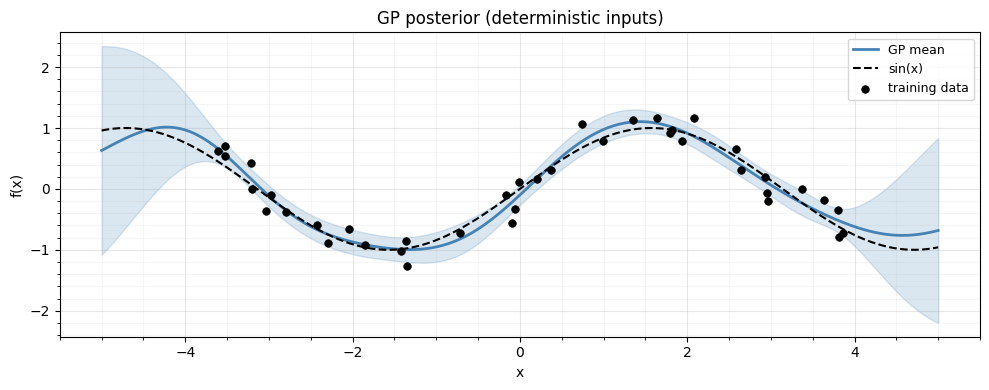

In [4]:
x_grid = jnp.linspace(-5, 5, 300)


def gp_predict_scalar(x_star):
    """Standard GP prediction at a single point. (D,) -> (mean, var)."""
    k_star = jax.vmap(lambda xi: rbf_kernel(x_star, xi))(X_train)
    mu = jnp.dot(k_star, alpha)
    solved = lx.linear_solve(K_op, k_star).value
    v = rbf_kernel(x_star, x_star) - jnp.dot(k_star, solved)
    return mu, jnp.maximum(v, 0.0)


mu_grid, var_grid = jax.vmap(gp_predict_scalar)(x_grid[:, None])
std_grid = jnp.sqrt(var_grid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    x_grid,
    mu_grid - 2 * std_grid,
    mu_grid + 2 * std_grid,
    alpha=0.2,
    color="steelblue",
)
ax.plot(x_grid, mu_grid, "steelblue", lw=2, label="GP mean", zorder=3)
ax.plot(x_grid, jnp.sin(x_grid), "k--", lw=1.5, label="sin(x)", zorder=4)
ax.scatter(
    X_train[:, 0],
    y_train,
    s=30,
    c="k",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="training data",
)
ax.set(xlabel="x", ylabel="f(x)", title="GP posterior (deterministic inputs)")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 2. Single uncertain prediction

Now suppose our test input is uncertain:
$x_* \sim \mathcal{N}(1.5, \; 0.3)$. We compare three approaches
to computing the predictive moments $\mathbb{E}[f(x_*)]$ and
$\mathrm{Var}[f(x_*)]$.

In [5]:
# Define the uncertain test input as a GaussianState
mu_test = jnp.array([1.5])
cov_test = lx.MatrixLinearOperator(jnp.array([[0.3]]), lx.positive_semidefinite_tag)
state_test = gaussx.GaussianState(mean=mu_test, cov=cov_test)

### 2a. Taylor integrator (linearisation)

In [6]:
taylor_integrator = gaussx.TaylorIntegrator()
mu_taylor, var_taylor = gaussx.uncertain_gp_predict(
    rbf_kernel, X_train, alpha, K_inv, state_test, taylor_integrator
)
print(f"Taylor:     mean = {mu_taylor:.4f},  var = {var_taylor:.4f}")

Taylor:     mean = 1.1024,  var = 0.0089


### 2b. Unscented integrator (sigma points)

In [7]:
unscented_integrator = gaussx.UnscentedIntegrator()
mu_ut, var_ut = gaussx.uncertain_gp_predict(
    rbf_kernel, X_train, alpha, K_inv, state_test, unscented_integrator
)
print(f"Unscented:  mean = {mu_ut:.4f},  var = {var_ut:.4f}")

Unscented:  mean = 0.9101,  var = 0.0000


### 2c. Monte Carlo

In [8]:
key, subkey = jr.split(key)
mu_mc, var_mc = gaussx.uncertain_gp_predict_mc(
    gp_predict_scalar, state_test, n_particles=1000, key=subkey
)
print(f"MC (1000):  mean = {mu_mc:.4f},  var = {var_mc:.4f}")

MC (1000):  mean = 0.9188,  var = 0.0724


### 2d. Comparison

All three methods should broadly agree, with Taylor slightly biased
in regions of high curvature and MC showing some sampling noise.

In [9]:
print(f"{'Method':<14} {'Mean':>8} {'Var':>8}")
print("-" * 32)
print(f"{'Taylor':<14} {mu_taylor:8.4f} {var_taylor:8.4f}")
print(f"{'Unscented':<14} {mu_ut:8.4f} {var_ut:8.4f}")
print(f"{'MC (1000)':<14} {mu_mc:8.4f} {var_mc:8.4f}")

Method             Mean      Var
--------------------------------
Taylor           1.1024   0.0089
Unscented        0.9101   0.0000
MC (1000)        0.9188   0.0724


## 3. Multi-step dynamics prediction (PILCO-style)

This is the core idea behind PILCO: chain uncertain GP predictions
to roll out a trajectory. At each step, the output distribution
becomes the input for the next step, and uncertainty grows.

We use a simple 1D dynamical system:
$x_{t+1} = \sin(x_t) + 0.1\,x_t + \varepsilon$, with
$\varepsilon \sim \mathcal{N}(0, 0.01)$.

### Generate dynamics data

In [10]:
dynamics_noise = 0.01

key, subkey = jr.split(key)
x_dyn = jr.uniform(subkey, (80, 1), minval=-3.0, maxval=3.0)
key, subkey = jr.split(key)
y_dyn = (
    jnp.sin(x_dyn[:, 0])
    + 0.1 * x_dyn[:, 0]
    + jnp.sqrt(dynamics_noise) * jr.normal(subkey, (80,))
)

# Train dynamics GP
K_dyn = jax.vmap(lambda x1: jax.vmap(lambda x2: rbf_kernel(x1, x2))(x_dyn))(x_dyn)
K_dyn_noisy = K_dyn + dynamics_noise * jnp.eye(x_dyn.shape[0])
K_dyn_op = lx.MatrixLinearOperator(K_dyn_noisy, lx.positive_semidefinite_tag)
alpha_dyn = gaussx.solve(K_dyn_op, y_dyn)
K_dyn_inv = lx.MatrixLinearOperator(
    jnp.linalg.inv(K_dyn_noisy), lx.positive_semidefinite_tag
)


def gp_predict_dyn(x_star):
    """Dynamics GP prediction: (D,) -> (mean, var)."""
    k_star = jax.vmap(lambda xi: rbf_kernel(x_star, xi))(x_dyn)
    mu = jnp.dot(k_star, alpha_dyn)
    solved = lx.linear_solve(K_dyn_op, k_star).value
    v = rbf_kernel(x_star, x_star) - jnp.dot(k_star, solved)
    return mu, jnp.maximum(v, 0.0)

### Roll out with uncertainty propagation

Starting from $x_0 \sim \mathcal{N}(0.5, 0.01)$, we chain uncertain
GP predictions for $H = 15$ steps. At each step we use
`AssumedDensityFilter` for KL-optimal Gaussian moment matching.

In [11]:
horizon = 15
integrator = gaussx.UnscentedIntegrator()
adf = gaussx.AssumedDensityFilter(
    n_samples=5000, regularization=1e-6, adaptive_regularization=True, key=jr.PRNGKey(0)
)

# Initial state
x0_mean = jnp.array([0.5])
x0_cov = lx.MatrixLinearOperator(jnp.array([[0.01]]), lx.positive_semidefinite_tag)
state_t = gaussx.GaussianState(mean=x0_mean, cov=x0_cov)

# Storage for trajectory
pred_means = [float(state_t.mean[0])]
pred_vars = [float(jnp.diag(state_t.cov.as_matrix())[0])]

for _t in range(horizon):
    mu_t, var_t = gaussx.uncertain_gp_predict(
        rbf_kernel, x_dyn, alpha_dyn, K_dyn_inv, state_t, integrator
    )
    # Build the next state from predicted moments
    next_mean = jnp.atleast_1d(mu_t)
    next_cov = lx.MatrixLinearOperator(
        jnp.atleast_2d(var_t + dynamics_noise), lx.positive_semidefinite_tag
    )
    state_t = gaussx.GaussianState(mean=next_mean, cov=next_cov)
    pred_means.append(float(mu_t))
    pred_vars.append(float(var_t + dynamics_noise))

pred_means = jnp.array(pred_means)
pred_stds = jnp.sqrt(jnp.array(pred_vars))

### Ground truth: simulate many particles

In [12]:
n_particles = 2000
key, subkey = jr.split(key)
particles = 0.5 + jnp.sqrt(0.01) * jr.normal(subkey, (n_particles,))

true_dynamics = lambda x: jnp.sin(x) + 0.1 * x

particle_traj = [particles]
for _t in range(horizon):
    key, subkey = jr.split(key)
    noise = jr.normal(subkey, particles.shape)
    particles = true_dynamics(particles) + jnp.sqrt(dynamics_noise) * noise
    particle_traj.append(particles)

particle_means = jnp.array([p.mean() for p in particle_traj])
particle_stds = jnp.array([p.std() for p in particle_traj])

### Plot: predicted trajectory vs ground truth

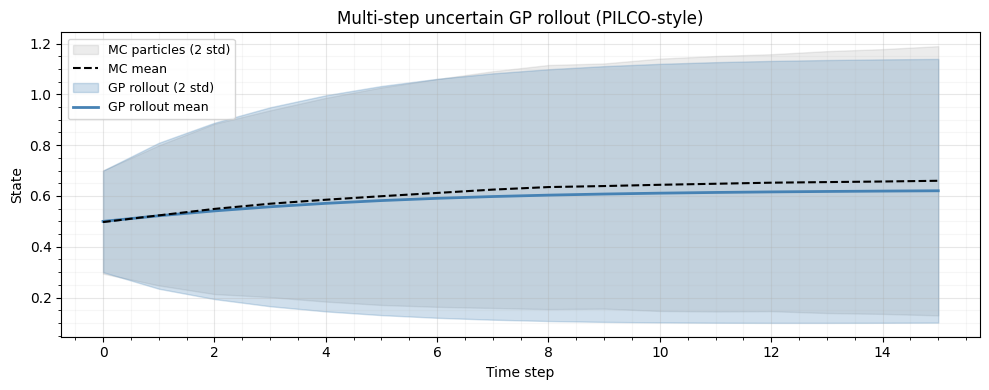

In [13]:
steps = jnp.arange(horizon + 1)

fig, ax = plt.subplots(figsize=(10, 4))
# Particle ground truth
ax.fill_between(
    steps,
    particle_means - 2 * particle_stds,
    particle_means + 2 * particle_stds,
    alpha=0.15,
    color="grey",
    label="MC particles (2 std)",
)
ax.plot(steps, particle_means, "k--", lw=1.5, label="MC mean", zorder=4)

# Uncertain GP rollout
ax.fill_between(
    steps,
    pred_means - 2 * pred_stds,
    pred_means + 2 * pred_stds,
    alpha=0.25,
    color="steelblue",
    label="GP rollout (2 std)",
)
ax.plot(steps, pred_means, "steelblue", lw=2, label="GP rollout mean", zorder=3)

ax.set(
    xlabel="Time step",
    ylabel="State",
    title="Multi-step uncertain GP rollout (PILCO-style)",
)
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

The GP rollout captures the trajectory shape while the uncertainty
fans out over the horizon -- exactly the behaviour exploited by PILCO
for policy gradient computation.

## 4. Expected cost under input uncertainty

In PILCO, the policy is optimised by differentiating the expected
cumulative cost through the uncertain rollout. Here we compute the
expected quadratic cost at a single step.

In [14]:
target = jnp.array([0.0])


def quadratic_cost(prediction, target):
    """Quadratic cost: (M,), (M,) -> scalar."""
    return jnp.sum((prediction - target) ** 2)


# Prediction function that maps input -> output mean
def gp_predict_mean(x):
    """GP dynamics mean prediction: (D,) -> (M,)."""
    k_star = jax.vmap(lambda xi: rbf_kernel(x, xi))(x_dyn)
    return jnp.atleast_1d(jnp.dot(k_star, alpha_dyn))


# Expected cost from an uncertain starting state
state_cost = gaussx.GaussianState(
    mean=jnp.array([1.0]),
    cov=lx.MatrixLinearOperator(jnp.array([[0.2]]), lx.positive_semidefinite_tag),
)

expected_cost = gaussx.cost_expectation(
    gp_predict_mean, quadratic_cost, state_cost, target, integrator
)
print(f"Expected quadratic cost: {expected_cost:.4f}")

Expected quadratic cost: 0.7958


This expected cost is differentiable with respect to the policy
parameters (not shown here), which is the basis of PILCO's
analytic policy gradient.

## 5. Expectation utilities

gaussx provides several utilities for computing expectations under
Gaussian distributions. These are the building blocks for the
uncertain GP machinery above.

### 5a. Mean expectation: $\mathbb{E}[f(x)]$

Compute the expected value of a function under a Gaussian input.

In [15]:
def cubic_fn(x):
    """A simple nonlinear function: (N,) -> (N,)."""
    return x**3 - 2.0 * x


state_exp = gaussx.GaussianState(
    mean=jnp.array([1.0]),
    cov=lx.MatrixLinearOperator(jnp.array([[0.5]]), lx.positive_semidefinite_tag),
)

E_f = gaussx.mean_expectation(cubic_fn, state_exp, integrator)
print(f"E[f(x)] with Unscented: {E_f}")

# Analytic check: E[x^3 - 2x] = mu^3 + 3*mu*sigma^2 - 2*mu
mu_val, sig2_val = 1.0, 0.5
analytic = mu_val**3 + 3.0 * mu_val * sig2_val - 2.0 * mu_val
print(f"Analytic E[x^3 - 2x]:  {analytic:.4f}")

E[f(x)] with Unscented: [0.5]
Analytic E[x^3 - 2x]:  0.5000


### 5b. Gradient expectation: $\mathbb{E}[\nabla f(x)]$ via Stein's lemma

Stein's lemma states that for $x \sim \mathcal{N}(\mu, \Sigma)$:

$$\mathbb{E}[\nabla f(x)] = \Sigma^{-1}\,\mathrm{Cov}[x, f(x)]$$

This is useful for computing expected gradients without differentiating
through the expectation integral.

In [16]:
def scalar_fn(x):
    """Scalar function: (N,) -> scalar."""
    return jnp.sum(jnp.sin(x))


E_grad = gaussx.gradient_expectation(scalar_fn, state_exp, integrator)
print(f"E[nabla sin(x)] at mu=1, sigma^2=0.5: {E_grad}")

# Compare: analytic E[cos(x)] = cos(mu) * exp(-sigma^2/2)
analytic_grad = jnp.cos(1.0) * jnp.exp(-0.5 * 0.5)
print(f"Analytic E[cos(x)] (moment generating fn):  {analytic_grad:.4f}")

E[nabla sin(x)] at mu=1, sigma^2=0.5: [0.54030226]
Analytic E[cos(x)] (moment generating fn):  0.4208


### 5c. Log-likelihood expectation: $\mathbb{E}[\log p(y \mid f(x))]$

For variational inference and EM with uncertain inputs, we need the
expected log-likelihood under the input distribution.

In [17]:
y_obs = 0.8


def log_likelihood_fn(x):
    """Gaussian log-likelihood: (N,) -> scalar."""
    pred = jnp.sin(x[0])
    return -0.5 * (y_obs - pred) ** 2 / noise_var - 0.5 * jnp.log(
        2.0 * jnp.pi * noise_var
    )


E_ll = gaussx.log_likelihood_expectation(log_likelihood_fn, state_exp, integrator)
print(f"E[log p(y|f(x))]: {E_ll:.4f}")

E[log p(y|f(x))]: -0.9374


## 6. AssumedDensityFilter with diagnostics

The `AssumedDensityFilter` projects the true (non-Gaussian) output
distribution onto the closest Gaussian in KL divergence. This is
the workhorse behind multi-step rollouts. The `integrate_with_diagnostics`
method additionally returns skewness and kurtosis of the output
samples, which helps assess whether the Gaussian approximation is
reasonable.

### 6a. Well-behaved case: near-linear function

In [18]:
def mild_nonlinear(x):
    """Mildly nonlinear: (N,) -> (N,)."""
    return jnp.tanh(0.5 * x)


state_diag = gaussx.GaussianState(
    mean=jnp.array([0.0]),
    cov=lx.MatrixLinearOperator(jnp.array([[0.3]]), lx.positive_semidefinite_tag),
)

result_mild, diagnostics_mild = adf.integrate_with_diagnostics(
    mild_nonlinear, state_diag
)
print("Mild nonlinearity:")
print(f"  Predicted mean: {result_mild.state.mean}")
print(f"  Skewness:       {diagnostics_mild['skewness']}")
print(f"  Kurtosis:       {diagnostics_mild['kurtosis']}")
print("  (Gaussian: skewness ~ 0, kurtosis ~ 3)")

Mild nonlinearity:
  Predicted mean: [-0.00669525]
  Skewness:       [0.03660105]
  Kurtosis:       [2.54982357]
  (Gaussian: skewness ~ 0, kurtosis ~ 3)


### 6b. Challenging case: strong nonlinearity

In [19]:
def strong_nonlinear(x):
    """Highly nonlinear: (N,) -> (N,)."""
    return jnp.sin(3.0 * x) * jnp.exp(-(x**2))


state_wide = gaussx.GaussianState(
    mean=jnp.array([0.5]),
    cov=lx.MatrixLinearOperator(jnp.array([[1.0]]), lx.positive_semidefinite_tag),
)

result_strong, diagnostics_strong = adf.integrate_with_diagnostics(
    strong_nonlinear, state_wide
)
print("Strong nonlinearity:")
print(f"  Predicted mean: {result_strong.state.mean}")
print(f"  Skewness:       {diagnostics_strong['skewness']}")
print(f"  Kurtosis:       {diagnostics_strong['kurtosis']}")
print("  (Deviations from 0 / 3 indicate non-Gaussianity)")

Strong nonlinearity:
  Predicted mean: [0.0548201]
  Skewness:       [-0.05444696]
  Kurtosis:       [2.36180005]
  (Deviations from 0 / 3 indicate non-Gaussianity)


When skewness is far from zero or kurtosis far from 3, the Gaussian
projection loses information. In such cases, consider:

- Using more sigma points / samples
- Reducing the prediction horizon
- Switching to a particle-based method

## Summary

| Tool | Purpose |
|------|---------|
| `uncertain_gp_predict` | Uncertain-input GP via quadrature |
| `uncertain_gp_predict_mc` | GP prediction with uncertain inputs via Monte Carlo |
| `AssumedDensityFilter` | KL-optimal Gaussian projection with diagnostics |
| `mean_expectation` | $\mathbb{E}[f(x)]$ under Gaussian input |
| `gradient_expectation` | $\mathbb{E}[\nabla f(x)]$ via Stein's lemma |
| `cost_expectation` | Expected cost under input uncertainty |
| `log_likelihood_expectation` | $\mathbb{E}[\log p(y \mid f(x))]$ |

These building blocks compose naturally:

1. **Train** a GP dynamics model on observed transitions
2. **Roll out** uncertain predictions with `uncertain_gp_predict`
3. **Evaluate** expected cost with `cost_expectation`
4. **Differentiate** through the whole pipeline with `jax.grad`

This is the computational recipe behind PILCO and related
model-based reinforcement learning algorithms.